In [1]:
import sys
sys.path.append('../../src')  # repo-relative: notebooks/pipeline/../../src
import os
import pandas as pd
import numpy as np
from config import *

train_df = pd.read_csv(os.path.join(PROC_DIR, 'train_step04.csv'))
test_df = pd.read_csv(os.path.join(PROC_DIR, 'test_step04.csv'))

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

print("\nFirst 3 rows of train:")
display(train_df[['hour', 'minute']].head(3))

Train shape: (77299, 14)
Test shape: (41778, 13)

First 3 rows of train:


,hour,minute
0,0,0
1,0,0
2,0,0


In [2]:
# sin and cos are used as a pair, not alone: sin(0)=sin(2π) but so does
# sin(π)=sin(π) at a totally different hour, so sin by itself can't
# distinguish e.g. hour 6 from hour 18. Together (sin, cos) form a unique
# point on the unit circle for every hour, which is what actually makes
# 23:00 and 00:00 sit next to each other instead of at opposite ends of a scale.
train_df['hour_sin'] = np.sin(2 * np.pi * train_df['hour'] / CYCLIC_FEATURES_MAX['decimal_hour'])
train_df['hour_cos'] = np.cos(2 * np.pi * train_df['hour'] / CYCLIC_FEATURES_MAX['decimal_hour'])

test_df['hour_sin'] = np.sin(2 * np.pi * test_df['hour'] / CYCLIC_FEATURES_MAX['decimal_hour'])
test_df['hour_cos'] = np.cos(2 * np.pi * test_df['hour'] / CYCLIC_FEATURES_MAX['decimal_hour'])

print(f"hour_sin: min={train_df['hour_sin'].min():.4f}, max={train_df['hour_sin'].max():.4f}, mean={train_df['hour_sin'].mean():.4f}")
print(f"hour_cos: min={train_df['hour_cos'].min():.4f}, max={train_df['hour_cos'].max():.4f}, mean={train_df['hour_cos'].mean():.4f}")

display(train_df[['hour', 'hour_sin', 'hour_cos']].head(5))

print(f"\nsin(0) = {np.sin(0):.4f}")
print(f"sin(2*pi) = {np.sin(2*np.pi):.4f}")

hour_sin: min=-1.0000, max=1.0000, mean=0.1828
hour_cos: min=-1.0000, max=1.0000, mean=0.0658


,hour,hour_sin,hour_cos
0,0,0.0,1.0
1,0,0.0,1.0
2,0,0.0,1.0
3,0,0.0,1.0
4,0,0.0,1.0



sin(0) = 0.0000
sin(2*pi) = -0.0000


In [3]:
is_peak_train = np.zeros(len(train_df), dtype=int)
is_peak_test = np.zeros(len(test_df), dtype=int)

for start, end in PEAK_HOURS:
    is_peak_train |= ((train_df['hour'] >= start) & (train_df['hour'] <= end)).values
    is_peak_test |= ((test_df['hour'] >= start) & (test_df['hour'] <= end)).values

train_df['is_peak_hour'] = is_peak_train
test_df['is_peak_hour'] = is_peak_test

print(train_df['is_peak_hour'].value_counts())

peak_mean = train_df[train_df['is_peak_hour'] == 1]['demand'].mean()
non_peak_mean = train_df[train_df['is_peak_hour'] == 0]['demand'].mean()

print(f"\nMean demand for peak hours: {peak_mean:.4f}")
print(f"Mean demand for non-peak hours: {non_peak_mean:.4f}")

is_peak_hour
0    61111
1    16188
Name: count, dtype: int64

Mean demand for peak hours: 0.0872
Mean demand for non-peak hours: 0.0957


In [4]:
start_bus, end_bus = BUSINESS_HOURS
train_df['is_business_hour'] = ((train_df['hour'] >= start_bus) & (train_df['hour'] <= end_bus)).astype(int)
test_df['is_business_hour'] = ((test_df['hour'] >= start_bus) & (test_df['hour'] <= end_bus)).astype(int)

print(train_df['is_business_hour'].value_counts())

bus_mean = train_df[train_df['is_business_hour'] == 1]['demand'].mean()
non_bus_mean = train_df[train_df['is_business_hour'] == 0]['demand'].mean()

print(f"\nMean demand for business hours: {bus_mean:.4f}")
print(f"Mean demand for non-business hours: {non_bus_mean:.4f}")

is_business_hour
0    46886
1    30413
Name: count, dtype: int64

Mean demand for business hours: 0.1036
Mean demand for non-business hours: 0.0877


In [5]:
start_night, end_night = NIGHT_HOURS
train_df['is_night'] = ((train_df['hour'] >= start_night) | (train_df['hour'] <= end_night)).astype(int)
test_df['is_night'] = ((test_df['hour'] >= start_night) | (test_df['hour'] <= end_night)).astype(int)

print(train_df['is_night'].value_counts())

night_mean = train_df[train_df['is_night'] == 1]['demand'].mean()
non_night_mean = train_df[train_df['is_night'] == 0]['demand'].mean()

print(f"\nMean demand for night hours: {night_mean:.4f}")
print(f"Mean demand for non-night hours: {non_night_mean:.4f}")

is_night
0    39599
1    37700
Name: count, dtype: int64

Mean demand for night hours: 0.0918
Mean demand for non-night hours: 0.0960


hour_squared: min=0, max=529, mean=129.84


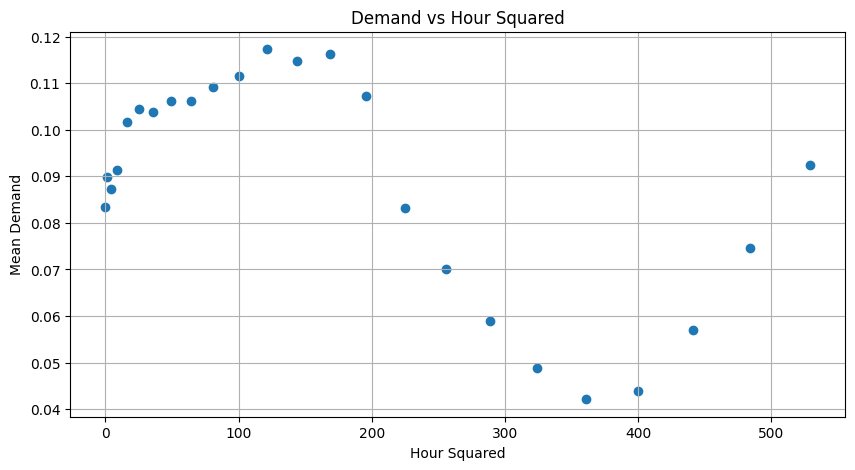

In [6]:
import matplotlib.pyplot as plt

# hour_squared alongside sin/cos: sin/cos capture the cyclical (repeating)
# shape of the day, but the bivariate EDA also showed a mid-day plateau that
# isn't a clean sinusoid — hour_squared gives tree splits an easy way to
# separate "far from midnight" from "near midnight" without relying on the
# model composing it from sin and cos itself.
train_df['hour_squared'] = np.square(train_df['hour'])
test_df['hour_squared'] = np.square(test_df['hour'])

print(f"hour_squared: min={train_df['hour_squared'].min()}, max={train_df['hour_squared'].max()}, mean={train_df['hour_squared'].mean():.2f}")

hour_demand = train_df.groupby('hour')['demand'].mean().reset_index()
hour_demand['hour_squared'] = np.square(hour_demand['hour'])

plt.figure(figsize=(10, 5))
plt.scatter(hour_demand['hour_squared'], hour_demand['demand'])
plt.title('Demand vs Hour Squared')
plt.xlabel('Hour Squared')
plt.ylabel('Mean Demand')
plt.grid(True)
os.makedirs(UNIVARIATE_PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(UNIVARIATE_PLOTS_DIR, 'hour_squared_vs_demand.png'))
plt.show()

In [7]:
temporal_cols = ['hour_sin', 'hour_cos', 'is_peak_hour', 'is_business_hour', 'is_night', 'hour_squared']

summary = train_df[temporal_cols].agg(['min', 'max', 'mean', lambda x: x.isnull().sum()]).T
summary.rename(columns={'<lambda>': 'null_count'}, inplace=True)
display(summary)

print(f"\nFull column list of train:")
print(train_df.columns.tolist())

,min,max,mean,null_count
hour_sin,-1.0,1.0,0.182811,0.0
hour_cos,-1.0,1.0,0.065783,0.0
is_peak_hour,0.0,1.0,0.209421,0.0
is_business_hour,0.0,1.0,0.393446,0.0
is_night,0.0,1.0,0.487717,0.0
hour_squared,0.0,529.0,129.839261,0.0



Full column list of train:
['day', 'demand', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'hour', 'minute', 'road_type_ord', 'weather_severity', 'latitude', 'longitude', 'geohash_target_enc', 'geohash_prefix_enc', 'hour_sin', 'hour_cos', 'is_peak_hour', 'is_business_hour', 'is_night', 'hour_squared']


In [8]:
train_df.to_csv(os.path.join(PROC_DIR, 'train_step05.csv'), index=False)
test_df.to_csv(os.path.join(PROC_DIR, 'test_step05.csv'), index=False)

print(f"Saved Train shape: {train_df.shape}")
print(f"Saved Test shape: {test_df.shape}")
print(f"Saved to: {os.path.join(PROC_DIR, 'train_step05.csv')}")
print(f"Saved to: {os.path.join(PROC_DIR, 'test_step05.csv')}")

Saved Train shape: (77299, 20)
Saved Test shape: (41778, 19)
Saved to: C:\TRAFFIC-DEMAND-FINAL\data\processed\train_step05.csv
Saved to: C:\TRAFFIC-DEMAND-FINAL\data\processed\test_step05.csv
